###  Section 1

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [3]:
#Load the Titanic dataset 
dataset=pd.read_csv("titanic_train_imputed.csv")

In [4]:
dataset

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone,survived
0,3,male,28.5,0,0,56.4958,S,Third,man,True,C,Southampton,True,1
1,2,male,28.5,0,0,0.0000,S,Second,man,True,C,Southampton,True,0
2,1,male,28.5,0,0,221.7792,S,First,man,True,C,Southampton,True,0
3,3,female,18.0,0,1,9.3500,S,Third,woman,False,C,Southampton,False,1
4,2,female,31.0,1,1,26.2500,S,Second,woman,False,C,Southampton,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,3,female,28.5,0,0,7.8792,Q,Third,woman,False,C,Queenstown,True,1
708,1,female,35.0,0,0,512.3292,C,First,woman,False,C,Cherbourg,True,1
709,3,female,48.0,1,3,34.3750,S,Third,woman,False,C,Southampton,False,0
710,1,male,47.0,0,0,38.5000,S,First,man,True,E,Southampton,True,0


In [5]:
x=dataset.iloc[ : , :-1]
y=dataset.iloc[ : ,-1]

In [6]:
x

,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alone
0,3,male,28.5,0,0,56.4958,S,Third,man,True,C,Southampton,True
1,2,male,28.5,0,0,0.0000,S,Second,man,True,C,Southampton,True
2,1,male,28.5,0,0,221.7792,S,First,man,True,C,Southampton,True
3,3,female,18.0,0,1,9.3500,S,Third,woman,False,C,Southampton,False
4,2,female,31.0,1,1,26.2500,S,Second,woman,False,C,Southampton,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,3,female,28.5,0,0,7.8792,Q,Third,woman,False,C,Queenstown,True
708,1,female,35.0,0,0,512.3292,C,First,woman,False,C,Cherbourg,True
709,3,female,48.0,1,3,34.3750,S,Third,woman,False,C,Southampton,False
710,1,male,47.0,0,0,38.5000,S,First,man,True,E,Southampton,True


In [7]:
y

0      1
1      0
2      0
3      1
4      1
      ..
707    1
708    1
709    0
710    0
711    1
Name: survived, Length: 712, dtype: int64

In [8]:
df=dataset.drop(["who","embarked","adult_male","pclass"],axis=1) #droped calums that are  having redundancy

In [9]:
df

,sex,age,sibsp,parch,fare,class,deck,embark_town,alone,survived
0,male,28.5,0,0,56.4958,Third,C,Southampton,True,1
1,male,28.5,0,0,0.0000,Second,C,Southampton,True,0
2,male,28.5,0,0,221.7792,First,C,Southampton,True,0
3,female,18.0,0,1,9.3500,Third,C,Southampton,False,1
4,female,31.0,1,1,26.2500,Second,C,Southampton,False,1
...,...,...,...,...,...,...,...,...,...,...
707,female,28.5,0,0,7.8792,Third,C,Queenstown,True,1
708,female,35.0,0,0,512.3292,First,C,Cherbourg,True,1
709,female,48.0,1,3,34.3750,Third,C,Southampton,False,0
710,male,47.0,0,0,38.5000,First,E,Southampton,True,0


In [10]:
df.info() #categorical valued columns are in strg datatype.

<class 'pandas.DataFrame'>
RangeIndex: 712 entries, 0 to 711
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sex          712 non-null    str    
 1   age          712 non-null    float64
 2   sibsp        712 non-null    int64  
 3   parch        712 non-null    int64  
 4   fare         712 non-null    float64
 5   class        712 non-null    str    
 6   deck         712 non-null    str    
 7   embark_town  712 non-null    str    
 8   alone        712 non-null    bool   
 9   survived     712 non-null    int64  
dtypes: bool(1), float64(2), int64(3), str(4)
memory usage: 50.9 KB


In [15]:
# Appling Label Encoding for ordinal categories , ordinal category is class column
from sklearn.preprocessing import OrdinalEncoder

encoder = OrdinalEncoder(categories=[['First','Second','Third']])

df['class'] = encoder.fit_transform(df[['class']])

ValueError: could not convert string to float: 'First'

In [16]:
df

,sex,age,sibsp,parch,fare,class,deck,embark_town,alone,survived
0,male,28.5,0,0,56.4958,2.0,C,Southampton,True,1
1,male,28.5,0,0,0.0000,1.0,C,Southampton,True,0
2,male,28.5,0,0,221.7792,0.0,C,Southampton,True,0
3,female,18.0,0,1,9.3500,2.0,C,Southampton,False,1
4,female,31.0,1,1,26.2500,1.0,C,Southampton,False,1
...,...,...,...,...,...,...,...,...,...,...
707,female,28.5,0,0,7.8792,2.0,C,Queenstown,True,1
708,female,35.0,0,0,512.3292,0.0,C,Cherbourg,True,1
709,female,48.0,1,3,34.3750,2.0,C,Southampton,False,0
710,male,47.0,0,0,38.5000,0.0,E,Southampton,True,0


In [23]:
# Appling One-Hot Encoding for nominal categories 
clms=["sex","deck","embark_town"]
dff=pd.get_dummies(df,columns=clms,dtype=int,drop_first=True)

In [24]:
dff

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0,0,56.4958,2.0,True,1,1,0,1,0,0,0,0,0,1
1,28.5,0,0,0.0000,1.0,True,0,1,0,1,0,0,0,0,0,1
2,28.5,0,0,221.7792,0.0,True,0,1,0,1,0,0,0,0,0,1
3,18.0,0,1,9.3500,2.0,False,1,0,0,1,0,0,0,0,0,1
4,31.0,1,1,26.2500,1.0,False,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0,0,7.8792,2.0,True,1,0,0,1,0,0,0,0,1,0
708,35.0,0,0,512.3292,0.0,True,1,0,0,1,0,0,0,0,0,0
709,48.0,1,3,34.3750,2.0,False,0,0,0,1,0,0,0,0,0,1
710,47.0,0,0,38.5000,0.0,True,0,1,0,0,0,1,0,0,0,1


In [25]:
#done binary encoding for "alone" column
dff['alone'] = dff['alone'].astype(int)

In [28]:
#finally after doing numericals and encoded features, new dataframe is
dff

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0,0,56.4958,2.0,1,1,1,0,1,0,0,0,0,0,1
1,28.5,0,0,0.0000,1.0,1,0,1,0,1,0,0,0,0,0,1
2,28.5,0,0,221.7792,0.0,1,0,1,0,1,0,0,0,0,0,1
3,18.0,0,1,9.3500,2.0,0,1,0,0,1,0,0,0,0,0,1
4,31.0,1,1,26.2500,1.0,0,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0,0,7.8792,2.0,1,1,0,0,1,0,0,0,0,1,0
708,35.0,0,0,512.3292,0.0,1,1,0,0,1,0,0,0,0,0,0
709,48.0,1,3,34.3750,2.0,0,0,0,0,1,0,0,0,0,0,1
710,47.0,0,0,38.5000,0.0,1,0,1,0,0,0,1,0,0,0,1


In [30]:
#saved the encoded dataset to csv file named "Encoded_dataset"
dff.to_csv("Encoded_dataset.csv", index=False)

### Section 2

In [58]:
#loaded the encoded dataset from section 1.
dataset=pd.read_csv("Encoded_dataset.csv")

In [59]:
dataset

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0,0,56.4958,2.0,1,1,1,0,1,0,0,0,0,0,1
1,28.5,0,0,0.0000,1.0,1,0,1,0,1,0,0,0,0,0,1
2,28.5,0,0,221.7792,0.0,1,0,1,0,1,0,0,0,0,0,1
3,18.0,0,1,9.3500,2.0,0,1,0,0,1,0,0,0,0,0,1
4,31.0,1,1,26.2500,1.0,0,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0,0,7.8792,2.0,1,1,0,0,1,0,0,0,0,1,0
708,35.0,0,0,512.3292,0.0,1,1,0,0,1,0,0,0,0,0,0
709,48.0,1,3,34.3750,2.0,0,0,0,0,1,0,0,0,0,0,1
710,47.0,0,0,38.5000,0.0,1,0,1,0,0,0,1,0,0,0,1


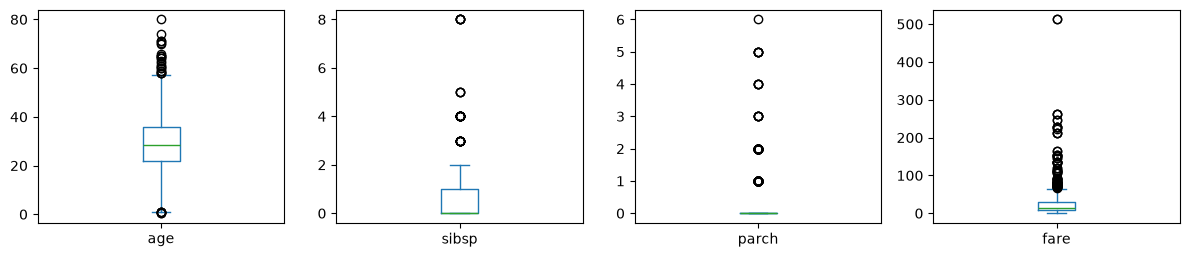

In [60]:
dataset[['age','sibsp','parch','fare']].plot(kind= "box", subplots=True, layout = (4,4),figsize=(12,10));
plt.tight_layout()

In [61]:
dataset.describe()

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.00000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,29.556067,0.492978,0.390449,31.819826,1.308989,0.609551,0.383427,0.644663,0.047753,0.83427,0.036517,0.040730,0.015449,0.005618,0.077247,0.727528
std,13.025273,1.060720,0.838134,48.059104,0.833563,0.488194,0.486563,0.478952,0.213393,0.37210,0.187704,0.197804,0.123419,0.074795,0.267171,0.445544
min,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,22.000000,0.000000,0.000000,7.895800,1.000000,0.000000,0.000000,0.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,28.500000,0.000000,0.000000,14.454200,2.000000,1.000000,0.000000,1.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
75%,36.000000,1.000000,0.000000,31.000000,2.000000,1.000000,1.000000,1.000000,0.000000,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,80.000000,8.000000,6.000000,512.329200,2.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [62]:
# Here the numericals columns that are "age,sibsp,parch,fare" are taken to a list and then in a for loop each column with be treated as series
# then it will calculate quantile 1 and 3, afterthat calculate IQR. according to IQR it takes appropriate lower and upper bound for box plot.
# for making the steps easier we are moving with for loop , so no need to write code for each columns IQR and upper&lower bound.
columns = ['age','sibsp','parch','fare']
for col in columns:
    series = dataset[col]
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print("\nColumn:", col)
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("IQR:", IQR)
    print("Lower:", lower)
    print("Upper:", upper)


Column: age
Q1: 22.0
Q3: 36.0
IQR: 14.0
Lower: 1.0
Upper: 57.0

Column: sibsp
Q1: 0.0
Q3: 1.0
IQR: 1.0
Lower: -1.5
Upper: 2.5

Column: parch
Q1: 0.0
Q3: 0.0
IQR: 0.0
Lower: 0.0
Upper: 0.0

Column: fare
Q1: 7.8958
Q3: 31.0
IQR: 23.1042
Lower: -26.7605
Upper: 65.6563


In [67]:
#capping for outliers.so the outliers will be replaced with upper and lower boundary values 
dataset['fare'] = dataset['fare'].clip(lower=-26.7605, upper=65.6563)

In [64]:
dataset['sibsp'] = dataset['sibsp'].clip(lower=-1.5, upper=2.5)

In [65]:
dataset['age'] = dataset['age'].clip(lower=1.0, upper=57.0)

In [66]:
dataset

,age,sibsp,parch,fare,class,alone,survived,sex_male,deck_B,deck_C,deck_D,deck_E,deck_F,deck_G,embark_town_Queenstown,embark_town_Southampton
0,28.5,0.0,0,56.4958,2.0,1,1,1,0,1,0,0,0,0,0,1
1,28.5,0.0,0,0.0000,1.0,1,0,1,0,1,0,0,0,0,0,1
2,28.5,0.0,0,65.6563,0.0,1,0,1,0,1,0,0,0,0,0,1
3,18.0,0.0,1,9.3500,2.0,0,1,0,0,1,0,0,0,0,0,1
4,31.0,1.0,1,26.2500,1.0,0,1,0,0,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
707,28.5,0.0,0,7.8792,2.0,1,1,0,0,1,0,0,0,0,1,0
708,35.0,0.0,0,65.6563,0.0,1,1,0,0,1,0,0,0,0,0,0
709,48.0,1.0,3,34.3750,2.0,0,0,0,0,1,0,0,0,0,0,1
710,47.0,0.0,0,38.5000,0.0,1,0,1,0,0,0,1,0,0,0,1


In [68]:
#after handling all the outliers converting the dataset to csv file
dataset.to_csv("outlier_treated_dataset.csv", index=False)

### Section 3

In [73]:
#loaded diabetes dataset
dataset=pd.read_csv("diabetes.csv")

In [84]:
#extracted target column from the dataset as y and other input features as x
x=dataset.iloc[ : , :-1]
y=dataset.iloc[ : ,-1]

In [85]:
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [86]:
y

0      1
1      0
2      1
3      0
4      1
      ..
763    0
764    0
765    0
766    1
767    0
Name: Outcome, Length: 768, dtype: int64

In [79]:
#performing target class distrubution
#taking values count in outcome column
#from this we can narrate that more people in class "0" . so cleary column imbalanced
print(dataset['Outcome'].value_counts())

Outcome
0    500
1    268
Name: count, dtype: int64


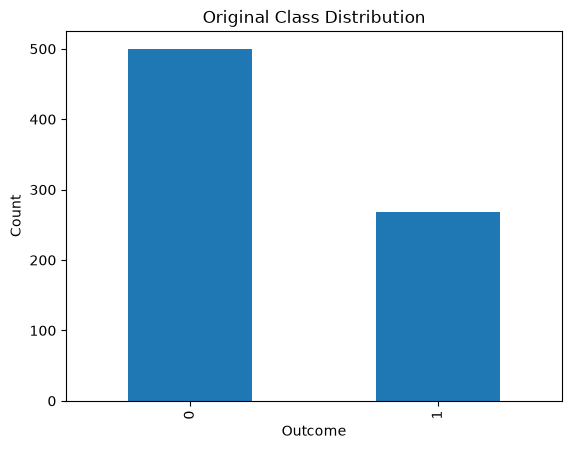

In [82]:
#the distribution of 0's and 1's in bar chart for easily understanding.
dataset['Outcome'].value_counts().plot(kind='bar')
plt.xlabel('Outcome')
plt.ylabel('Count')
plt.title('Original Class Distribution')
plt.show()

In [100]:
#under sampling reduces the majority class, that is class "0",here x_under are the features and y_under  are the target column.
#imblearn is the module used for sampling techniques
from imblearn.under_sampling import RandomUnderSampler
under_sampler = RandomUnderSampler(random_state=42)
X_under, y_under = under_sampler.fit_resample(x,y)

In [92]:
#after doing under sampling the dataset became balanced.
print(y_under.value_counts())

Outcome
0    268
1    268
Name: count, dtype: int64


In [104]:
#over sampling additionaly add some extra duplicate data to the dataset for getting minority class to balanced.
from imblearn.over_sampling import RandomOverSampler
over_sampler = RandomOverSampler(random_state=42)
X_over, y_over = over_sampler.fit_resample(x,y) #analyze the class imbalance and then create a new balanced X and y.

In [105]:
print(y_over.value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


In [109]:
#SMOTE creates synthetic observations for the minority class.smote is an over sampling technique used for balancing the dataset.
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(x,y)

In [107]:
print(y_smote.value_counts())

Outcome
1    500
0    500
Name: count, dtype: int64


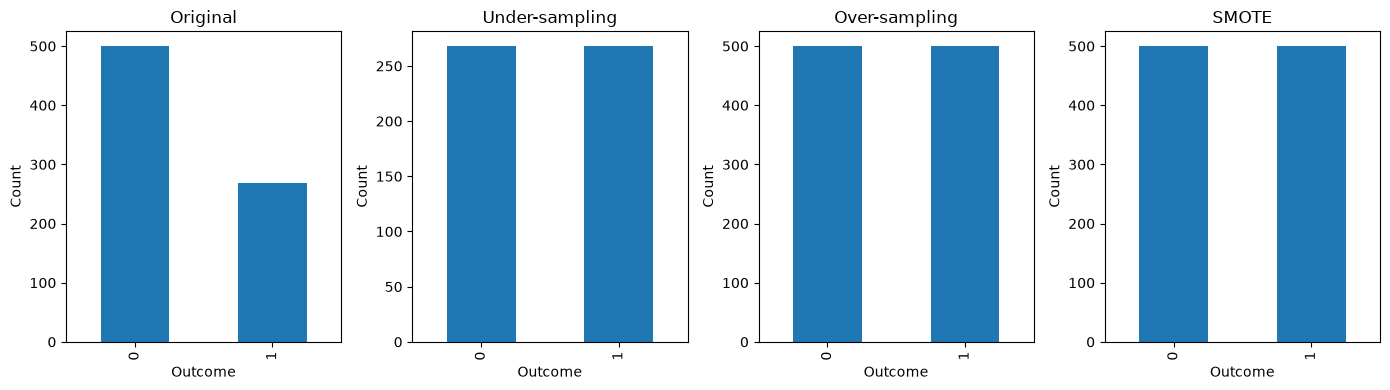

In [108]:
#comparison of the class imbalancing before and after applyning sampling techniques
import matplotlib.pyplot as plt
distributions = {
    'Original': y.value_counts(),
    'Under-sampling': y_under.value_counts(),
    'Over-sampling': y_over.value_counts(),
    'SMOTE': y_smote.value_counts()
}
fig, axes = plt.subplots(1, 4, figsize=(14, 4))
for ax, (name, counts) in zip(axes, distributions.items()):
    counts.sort_index().plot(kind='bar', ax=ax)
    ax.set_title(name)
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

### Section 4

In [3]:
dataset=pd.read_csv("loan.csv")

In [4]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    str    
 1   Gender             601 non-null    str    
 2   Married            611 non-null    str    
 3   Dependents         599 non-null    str    
 4   Education          614 non-null    str    
 5   Self_Employed      582 non-null    str    
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    str    
 12  Loan_Status        614 non-null    str    
dtypes: float64(4), int64(1), str(8)
memory usage: 62.5 KB


In [5]:
dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [12]:
#datatype of dependents are in str. so,converting it into intiger.
dataset['Dependents'].unique()

array([ 0.,  1.,  2.,  3., nan])

In [13]:
#here dependencies are 3+ that is in str format so it is replaced with 3.
dataset['Dependents'] = dataset['Dependents'].replace('3+', '3')

In [14]:
# converted the datatype to float
dataset["Dependents"]=dataset["Dependents"].astype(float)

In [11]:
dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [19]:
#so their is not any duplicate rows.
dataset.duplicated().sum()

np.int64(0)

In [17]:
# now their are some missing values.
dataset.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [31]:
# now we can handle the missing values in each columns.
#first we are considering categorical colums. and filling the missing values with mode.
dataset['Gender']=dataset['Gender'].fillna(dataset['Gender'].mode()[0], inplace=True)
dataset['Married']=dataset['Married'].fillna(dataset['Married'].mode()[0], inplace=True)
dataset['Dependents']=dataset['Dependents'].fillna(dataset['Dependents'].mode()[0], inplace=True)
dataset['Self_Employed']=dataset['Self_Employed'].fillna(dataset['Self_Employed'].mode()[0], inplace=True)

In [32]:
import warnings
warnings.filterwarnings('ignore')

In [33]:
# considering numerical missing value colums . and filling it with median.
#Credit_History is a categorical/binary variable, not a continuous numerical measurement. so thats why it mode of that column is taken.
dataset['LoanAmount']=dataset['LoanAmount'].fillna(dataset['LoanAmount'].median(), inplace=True)
dataset['Loan_Amount_Term']=dataset['Loan_Amount_Term'].fillna(dataset['Loan_Amount_Term'].median(), inplace=True)
dataset['Credit_History']=dataset['Credit_History'].fillna(dataset['Credit_History'].mode()[0], inplace=True)

In [35]:
dataset.isnull().sum()
# now all the missing values are filled .

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [36]:
dataset

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [37]:
# loan id dont have any role in this prediction . so, we can drop that column.
dataset.drop('Loan_ID', axis=1, inplace=True)

In [38]:
dataset

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2.0,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [39]:
# these are the column we are going to handle the outliers . bcz these columns having contineous numerical values
col=["ApplicantIncome","CoapplicantIncome","LoanAmount"]

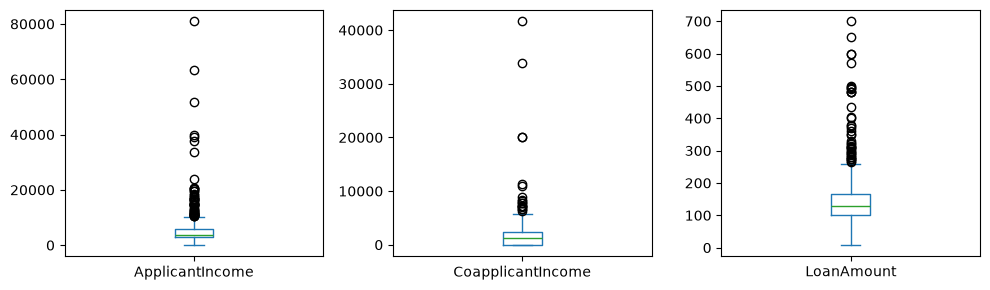

In [45]:
dataset[["ApplicantIncome","CoapplicantIncome","LoanAmount"]].plot(kind="box",subplots=True,layout= (1,3),figsize=(10,3));
plt.tight_layout()

In [46]:
#IQR method
Q1 = dataset['ApplicantIncome'].quantile(0.25)
Q3 = dataset['ApplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR
print("Lower:", lower)
print("Upper:", upper)

Lower: -1498.75
Upper: 10171.25


In [47]:
print("outlier that is upper than upper bound : ",len(dataset[dataset["ApplicantIncome"] > upper]))

outlier that is upper than upper bound :  50


In [48]:
print("outlier less than lower bound : ",len(dataset[dataset['ApplicantIncome']< lower]))

outlier less than lower bound :  0


In [49]:
# now we are not simply cutting the outliers instead we are choosing capping.bcz high values can be genuine observations, not errors.
dataset['ApplicantIncome'] = dataset['ApplicantIncome'].clip(lower, upper)

In [52]:
# repeating this to coapplicantincome and loanamount colums.
Q1 = dataset['CoapplicantIncome'].quantile(0.25)
Q3 = dataset['CoapplicantIncome'].quantile(0.75)
IQR = Q3 - Q1
llower = Q1 - 1.5 * IQR
uupper = Q3 + 1.5 * IQR
print("Lower:", llower)
print("Upper:", uupper)

Lower: -3445.875
Upper: 5743.125


In [54]:
print("outlier that is upper than upper bound : ",len(dataset[dataset["CoapplicantIncome"] > uupper]))

outlier that is upper than upper bound :  18


In [59]:
print("outlier less than lower bound : ",len(dataset[dataset['CoapplicantIncome']< llower]))

outlier less than lower bound :  0


In [60]:
dataset['CoapplicantIncome'] = dataset['CoapplicantIncome'].clip(llower, uupper)

In [61]:
Q1 = dataset['LoanAmount'].quantile(0.25)
Q3 = dataset['LoanAmount'].quantile(0.75)
IQR = Q3 - Q1
lllower = Q1 - 1.5 * IQR
uuupper = Q3 + 1.5 * IQR
print("Lower:", lllower)
print("Upper:", uuupper)

Lower: 3.5
Upper: 261.5


In [62]:
print("outlier that is upper than upper bound : ",len(dataset[dataset["LoanAmount"] > uuupper]))

outlier that is upper than upper bound :  41


In [63]:
print("outlier less than lower bound : ",len(dataset[dataset['LoanAmount']< lllower]))

outlier less than lower bound :  0


In [67]:
dataset['LoanAmount'] = dataset['LoanAmount'].clip(lllower, uuupper)

In [68]:
dataset

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0.0,Graduate,No,5849.0,3.5,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1.0,Graduate,No,4583.0,261.5,128.0,360.0,1.0,Rural,N
2,Male,Yes,0.0,Graduate,Yes,3000.0,3.5,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0.0,Not Graduate,No,2583.0,261.5,120.0,360.0,1.0,Urban,Y
4,Male,No,0.0,Graduate,No,6000.0,3.5,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0.0,Graduate,No,2900.0,3.5,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3.0,Graduate,No,4106.0,3.5,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1.0,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2.0,Graduate,No,7583.0,3.5,187.0,360.0,1.0,Urban,Y


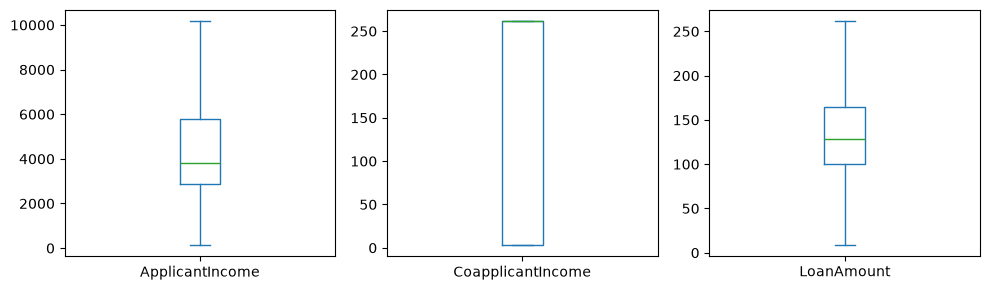

In [70]:
#after capping all ouliers are handled.
dataset[["ApplicantIncome","CoapplicantIncome","LoanAmount"]].plot(kind="box",subplots=True,layout= (1,3),figsize=(10,3));
plt.tight_layout()

In [71]:
# label encoding for  columns with two categorical values.
dataset['Gender'] = dataset['Gender'].map({'Male': 1,'Female': 0})
dataset['Married'] = dataset['Married'].map({'Yes': 1,'No': 0})
dataset['Education'] = dataset['Education'].map({'Graduate': 1,'Not Graduate': 0})
dataset['Self_Employed'] = dataset['Self_Employed'].map({'Yes': 1,'No': 0})

In [74]:
# one hot encoding for other categorical colum having a order in their values.
dataset = pd.get_dummies(dataset,columns=['Property_Area'],drop_first=True,dtype=int)

KeyError: "None of [Index(['Property_Area'], dtype='str')] are in the [columns]"

In [76]:
dataset

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849.0,3.5,128.0,360.0,1.0,Y,False,True
1,1,1,1.0,1,0,4583.0,261.5,128.0,360.0,1.0,N,False,False
2,1,1,0.0,1,1,3000.0,3.5,66.0,360.0,1.0,Y,False,True
3,1,1,0.0,0,0,2583.0,261.5,120.0,360.0,1.0,Y,False,True
4,1,0,0.0,1,0,6000.0,3.5,141.0,360.0,1.0,Y,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,1,0,2900.0,3.5,71.0,360.0,1.0,Y,False,False
610,1,1,3.0,1,0,4106.0,3.5,40.0,180.0,1.0,Y,False,False
611,1,1,1.0,1,0,8072.0,240.0,253.0,360.0,1.0,Y,False,True
612,1,1,2.0,1,0,7583.0,3.5,187.0,360.0,1.0,Y,False,True


In [79]:
# colums Property_Area_Semiurban	Property_Area_Urban are in boolean . so it can be converted to int using astype
dataset['Property_Area_Semiurban'] = dataset['Property_Area_Semiurban'].astype(int)
dataset['Property_Area_Urban'] = dataset['Property_Area_Urban'].astype(int)

In [78]:
dataset

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849.0,3.5,128.0,360.0,1.0,Y,0,1
1,1,1,1.0,1,0,4583.0,261.5,128.0,360.0,1.0,N,0,0
2,1,1,0.0,1,1,3000.0,3.5,66.0,360.0,1.0,Y,0,1
3,1,1,0.0,0,0,2583.0,261.5,120.0,360.0,1.0,Y,0,1
4,1,0,0.0,1,0,6000.0,3.5,141.0,360.0,1.0,Y,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,1,0,2900.0,3.5,71.0,360.0,1.0,Y,0,0
610,1,1,3.0,1,0,4106.0,3.5,40.0,180.0,1.0,Y,0,0
611,1,1,1.0,1,0,8072.0,240.0,253.0,360.0,1.0,Y,0,1
612,1,1,2.0,1,0,7583.0,3.5,187.0,360.0,1.0,Y,0,1


In [81]:
# now we can see the imbalanced data 
dataset['Loan_Status'].value_counts()

Loan_Status
Y    422
N    192
Name: count, dtype: int64

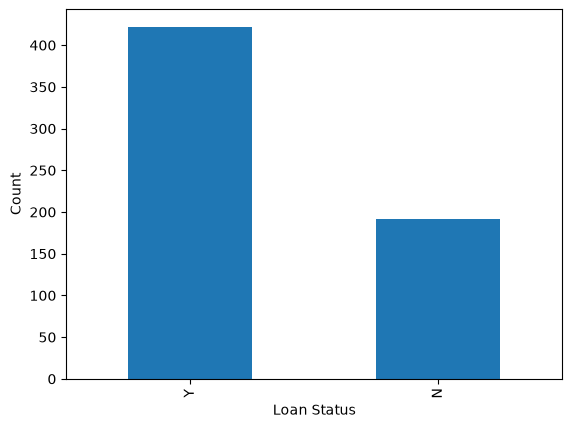

In [82]:
import matplotlib.pyplot as plt
dataset['Loan_Status'].value_counts().plot(kind='bar')
plt.xlabel('Loan Status')
plt.ylabel('Count')
plt.show()

In [91]:
x = dataset.drop('Loan_Status', axis=1)
y = dataset['Loan_Status']

In [92]:
x

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849.0,3.5,128.0,360.0,1.0,0,1
1,1,1,1.0,1,0,4583.0,261.5,128.0,360.0,1.0,0,0
2,1,1,0.0,1,1,3000.0,3.5,66.0,360.0,1.0,0,1
3,1,1,0.0,0,0,2583.0,261.5,120.0,360.0,1.0,0,1
4,1,0,0.0,1,0,6000.0,3.5,141.0,360.0,1.0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,1,0,2900.0,3.5,71.0,360.0,1.0,0,0
610,1,1,3.0,1,0,4106.0,3.5,40.0,180.0,1.0,0,0
611,1,1,1.0,1,0,8072.0,240.0,253.0,360.0,1.0,0,1
612,1,1,2.0,1,0,7583.0,3.5,187.0,360.0,1.0,0,1


In [93]:
y

0      Y
1      N
2      Y
3      Y
4      Y
      ..
609    Y
610    Y
611    Y
612    Y
613    N
Name: Loan_Status, Length: 614, dtype: str

In [95]:
#before doing sampling data is splitted to tarin and test
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y,test_size=0.2,random_state=42,stratify=y)

In [96]:
# we are applying SMOTE here.
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

In [97]:
print(y_train.value_counts())

Loan_Status
Y    337
N    337
Name: count, dtype: int64


In [98]:
dataset

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Loan_Status,Property_Area_Semiurban,Property_Area_Urban
0,1,0,0.0,1,0,5849.0,3.5,128.0,360.0,1.0,Y,0,1
1,1,1,1.0,1,0,4583.0,261.5,128.0,360.0,1.0,N,0,0
2,1,1,0.0,1,1,3000.0,3.5,66.0,360.0,1.0,Y,0,1
3,1,1,0.0,0,0,2583.0,261.5,120.0,360.0,1.0,Y,0,1
4,1,0,0.0,1,0,6000.0,3.5,141.0,360.0,1.0,Y,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0,0,0.0,1,0,2900.0,3.5,71.0,360.0,1.0,Y,0,0
610,1,1,3.0,1,0,4106.0,3.5,40.0,180.0,1.0,Y,0,0
611,1,1,1.0,1,0,8072.0,240.0,253.0,360.0,1.0,Y,0,1
612,1,1,2.0,1,0,7583.0,3.5,187.0,360.0,1.0,Y,0,1


In [100]:
# scaling the data with standarscaler method
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train) #here fit_transform is used beacuse The scaler learns the mean and standard deviation from the training data and scales it.
X_test_scaled = scaler.transform(X_test) #uses the same values learned from the training data.